In [10]:
import math
import torch
from torch import nn
from torch.nn import functional as F

import mypreprocess as mpp
import mylib

In [11]:
## 初始化模型参数
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size   # 语言模型，输入和输出来自相同词表，维度相同

    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01
    
    # 隐藏层
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 输出层
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

## RNN 模型
# 初始化时返回隐状态
def init_rnn_state(batch_size, num_hiddens, device):
    # 返回元组，容易处理隐状态包含多变量的情况
    return (torch.zeros((batch_size, num_hiddens), device=device), )


# 在一个时间步内计算隐状态和输出
def rnn(inputs, state, params):
    # inputs: (时间步数量, 批量大小, 词表大小)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # X: (批量大小, 词表大小)
    for X in inputs:
        H = torch.tanh(X @ W_xh + H @ W_hh + b_h)
        Y = H @ W_hq + b_q
        outputs.append(Y)
    # 返回: (时间步数*批量大小, 词表大小) 由于前两个维度cat
    return torch.cat(outputs, dim=0), (H,)


## 预测函数
def predict_ch8(prefix, num_preds, net, vocab, device):
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    # warm-up  预热期( 更新隐状态，但不进行预测 )
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    # 预测 num_preds 步
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.to_tokens(i) for i in outputs])


## 梯度裁剪
def grad_clipping(net, theta):
    """梯度裁剪 方向一致但限制梯度范数不超过theta
        g <- min(1, theta/norm(g) ) * g  
        可以防止梯度爆炸，但不能应对梯度消失"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    # 计算所有模型参数梯度的范数
    # torch.sum对所有元素求和，这里的sum对生成器表达式求和
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm
    

## 模型训练
# 一个epoch
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state, timer = None, mylib.Timer()
    metric = mylib.Accumulator(2)   # 训练损失和，词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 第一次迭代 或 随机抽样 时初始化state
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            # 对于顺序抽样，由于下一个小批量数据中第i个子序列样本与当前第i个子
            # 序列样本相邻，因此当前小批量数据最后一个样本的隐状态，将用于初始
            # 化下一个小批量数据第一个样本的隐状态。因此隐状态的历史信息可以在
            # 一个迭代周期内流经相邻的子序列。然而任何一点隐状态的计算，都依赖
            # 于同一迭代周期中前面所有的小批量数据，导致梯度计算变得复杂。为降
            # 低计算量，通过分离梯度，使得隐状态的梯度计算总是限制在一个小批量
            # 数据的时间步内。
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # state对于nn.GRU是张量
                state.detach_()
            else:
                # state对于nn.LSTM或对于从零开始实现的模型是个张量
                for s in state:
                    s.detach_()
        # y 大致形状为 (时间步1第一个batch的结果，时间步1第二个batch的结果，...
        # 时间步2第一个batch的结果，时间步2第二个batch的结果，...)
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)

        l = loss(y_hat, y.long()).mean()   # 注意此处y_hat为one-hot, y为label值
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            # 已调用过mean，不用再平均了
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    # 输出的第一个值为perplexity 困惑度
    # 最好的情况下为1， 最坏的情况下为正无穷
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()


# epochs
def train_ch8(net, train_iter, vocab, lr, num_epochs, device, use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    animator = mylib.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: mylib.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 训练和预测
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))



# 创建类来包装函数
class RNNModelScratch:
    """RNN模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        # X: (批量大小, 时间步数) -> (时间步数, 批量大小, 词表大小)
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)
    
    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)
        



In [30]:
batch_size, num_steps = 128, 200
train_iter, vocab = mpp.load_data_time_machine(batch_size, num_steps, use_random_iter=True, max_tokens=200000)

In [14]:
# 测试维度
X = torch.arange(10).reshape((2, 5))

num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, mylib.try_gpu(), get_params,
                      init_rnn_state, rnn)
state = net.begin_state(X.shape[0], mylib.try_gpu())
Y, new_state = net(X.to(mylib.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

In [15]:
# 测试predict
predict_ch8('time traveller ', 10, net, vocab, mylib.try_gpu())

'time traveller bckurhfwjp'

困惑度 1.7, 136280.8 词元/秒 cuda:0
time traveller and the world and leasiving on the huglyst disked
traveller latthes werd aficormabsuale blievethis thought i 


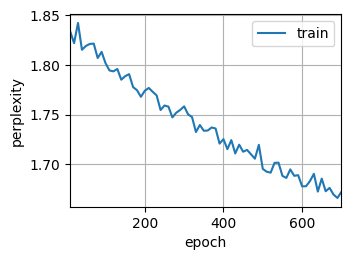

In [33]:
# 随机抽样
num_epochs, lr = 700, 0.5
train_ch8(net, train_iter, vocab, lr, num_epochs, device=mylib.try_gpu(), use_random_iter=True)

In [ ]:
# 顺序抽样
train_iter, vocab = mpp.load_data_time_machine(batch_size, num_steps, use_random_iter=False)
train_ch8(net, train_iter, vocab, lr, num_epochs, device=mylib.try_gpu(), use_random_iter=False)

0
1


In [35]:
predict_ch8('world war is like', 200, net, vocab, mylib.try_gpu())

'world war is like andmyoowasd a tcun confusion it mast and s of hapaning a miled hos i bent and the gamanced in a start of dising at first me luginions of the distercation lakner was remenus ane stully no think to fee'